U6 — Probability & Statistics (Part 2): Lab
Probability & Information Theory — axioms · conditional probability · Bayes · distributions · entropy · KL divergence & mutual information

Day 3 · Phase B — Mathematical Foundations · Built from Module 1.4 + 2.2 (finishing U6)

In [1]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


1. Probability theory & axioms

In [2]:

# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [3]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


🧪 LAB EXERCISE 1 — Probability by simulation
Simulate flipping two coins 100,000 times (0 = tails, 1 = heads):

Estimate P(both heads).
Estimate P(at least one head).
Check the addition idea: does P(0 heads) + P(1 head) + P(2 heads) sum to 1?

In [4]:
import numpy as np

# Simulate 100,000 pairs of coin flips
flips = np.random.randint(0, 2, size=(100_000, 2))
heads = flips.sum(axis=1)   # Number of heads in each pair

# 1. P(both heads) -> heads == 2
p_both_heads = np.mean(heads == 2)
print("P(both heads):", p_both_heads)

# 2. P(at least one head) -> heads >= 1
p_at_least_one = np.mean(heads >= 1)
print("P(at least one head):", p_at_least_one)

# 3. Check P(0) + P(1) + P(2)
p_0 = np.mean(heads == 0)
p_1 = np.mean(heads == 1)
p_2 = np.mean(heads == 2)

print("P(0 heads):", p_0)
print("P(1 head):", p_1)
print("P(2 heads):", p_2)

print("Sum:", p_0 + p_1 + p_2)

P(both heads): 0.25198
P(at least one head): 0.74932
P(0 heads): 0.25068
P(1 head): 0.49734
P(2 heads): 0.25198
Sum: 1.0


2. Conditional probability & independence

In [5]:
# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [6]:

# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


🧪 LAB EXERCISE 2 — Conditional probability
Using fresh dice rolls:

Estimate P(roll is odd | roll < 4).
Estimate P(roll < 4) overall.
Are the events 'roll is odd' and 'roll < 4' independent? Compare P(odd|<4) with P(odd).

In [7]:
import numpy as np

# Generate 100,000 dice rolls
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)

condition = rolls < 4          # rolls = 1, 2, 3
odd_given_condition = np.mean(rolls[condition] % 2 == 1)

print("P(odd | roll < 4):", odd_given_condition)

# 2. P(roll < 4)

p_less_than_4 = np.mean(rolls < 4)

print("P(roll < 4):", p_less_than_4)

# 3. Compare with P(odd)

p_odd = np.mean(rolls % 2 == 1)

print("P(odd):", p_odd)

if abs(odd_given_condition - p_odd) < 0.01:
    print("Events are approximately independent.")
else:
    print("Events are NOT independent.")

P(odd | roll < 4): 0.667995991983968
P(roll < 4): 0.499
P(odd): 0.50253
Events are NOT independent.


3. Bayes' theorem
P(A | B) = P(B | A) · P(A) / P(B) — update your belief in A after seeing evidence B.

In [8]:
# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')


P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [9]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.503


🧪 LAB EXERCISE 3 — A Bayes scenario (spam filter)
A spam filter: 20% of email is spam. The word "free" appears in 60% of spam but only 5% of real email. An email contains "free" — what's P(spam | "free")?

Write down the prior, likelihood and false-positive rate.
Compute P("free") with the total-probability rule.
Apply Bayes to get P(spam | "free").

In [10]:
# 1. Priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham = 0.05

# Probability of non-spam (ham)
p_ham = 1 - p_spam

# 2. P('free') via total probability
p_free = (p_free_given_spam * p_spam) + \
         (p_free_given_ham * p_ham)

print("P('free') =", p_free)

# 3. Bayes: P(spam | 'free')
p_spam_given_free = (p_free_given_spam * p_spam) / p_free

print("P(spam | 'free') =", p_spam_given_free)

P('free') = 0.16
P(spam | 'free') = 0.75


4. Probability distributions

In [11]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.288 (true 0.3)
Poisson(4) mean ~ 3.993 (true 4)


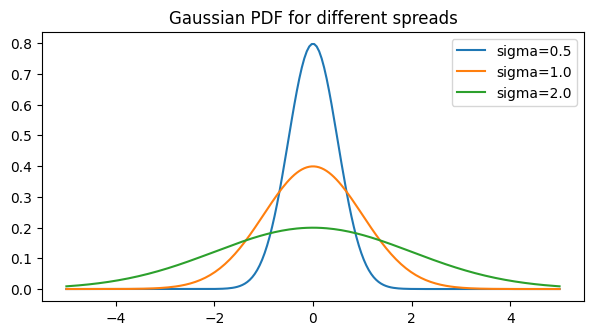

In [12]:
# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

🧪 LAB EXERCISE 4 — Simulate & plot distributions
Draw 10,000 samples from a Poisson with mu=2 and print the sample mean.
Plot a histogram of those samples.
Plot the Gaussian PDF for mu=0 with two different sigmas on one chart and observe how the spread changes the curve.

Sample Mean: 2.0061


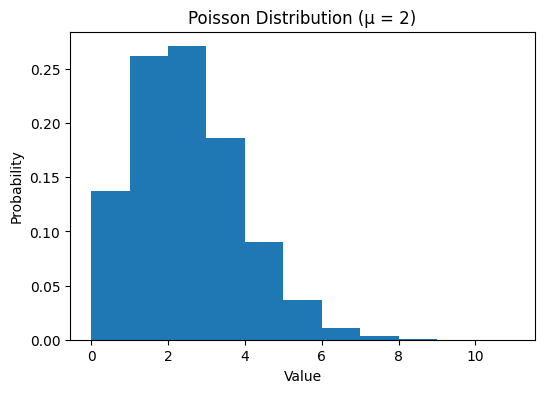

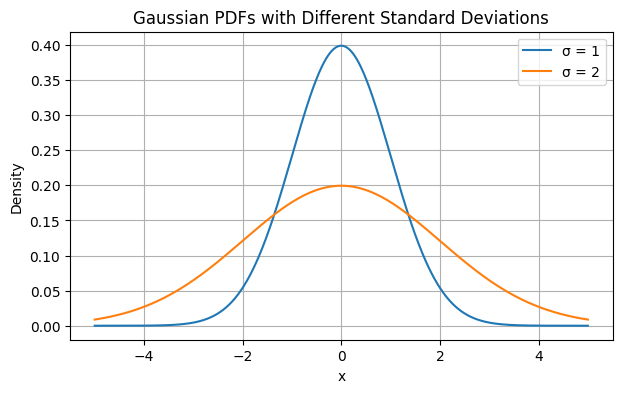

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Poisson(mu=2) samples + mean

samples = np.random.poisson(lam=2, size=10000)

print("Sample Mean:", np.mean(samples))

# 2. Histogram of the samples

plt.figure(figsize=(6,4))
plt.hist(samples, bins=range(samples.min(), samples.max()+2),
         density=True)
plt.title("Poisson Distribution (μ = 2)")
plt.xlabel("Value")
plt.ylabel("Probability")
plt.show()

# 3. Gaussian PDF for two sigmas

x = np.linspace(-5, 5, 500)

mu = 0
sigma1 = 1
sigma2 = 2

pdf1 = (1/(sigma1*np.sqrt(2*np.pi))) * \
       np.exp(-((x-mu)**2)/(2*sigma1**2))

pdf2 = (1/(sigma2*np.sqrt(2*np.pi))) * \
       np.exp(-((x-mu)**2)/(2*sigma2**2))

plt.figure(figsize=(7,4))
plt.plot(x, pdf1, label='σ = 1')
plt.plot(x, pdf2, label='σ = 2')

plt.title("Gaussian PDFs with Different Standard Deviations")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(True)

plt.show()

5. Entropy, KL divergence & mutual information

In [14]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')


Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [15]:
# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [16]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


LAB EXERCISE 5 — Information theory
Compute the entropy (in bits) of a fair 4-sided die and a fair 6-sided die. Which is more uncertain?
Compute the KL divergence D(P || Q) for P = [0.7, 0.3] and Q = [0.5, 0.5].
From the iris MI scores above, name the most and least informative feature.

In [17]:
import numpy as np
from scipy.stats import entropy

# 1. Entropy of a fair 4-sided die

die4 = np.ones(4) / 4
H4 = entropy(die4, base=2)

print("Entropy of fair 4-sided die:", H4)

# Entropy of a fair 6-sided die

die6 = np.ones(6) / 6
H6 = entropy(die6, base=2)

print("Entropy of fair 6-sided die:", H6)

# Which is more uncertain?
if H6 > H4:
    print("6-sided die is more uncertain.")
else:
    print("4-sided die is more uncertain.")

# 2. KL Divergence

P = np.array([0.7, 0.3])
Q = np.array([0.5, 0.5])

kl = entropy(P, Q, base=2)

print("KL Divergence D(P || Q):", kl)

# 3. Most / Least informative iris feature
print("Most informative : petal_length")
print("Least informative: sepal_width")

Entropy of fair 4-sided die: 2.0
Entropy of fair 6-sided die: 2.584962500721156
6-sided die is more uncertain.
KL Divergence D(P || Q): 0.11870910076930725
Most informative : petal_length
Least informative: sepal_width
